<a href="https://colab.research.google.com/github/Arya20040110/med_image_processing/blob/main/Med_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Processing mri.jpg...


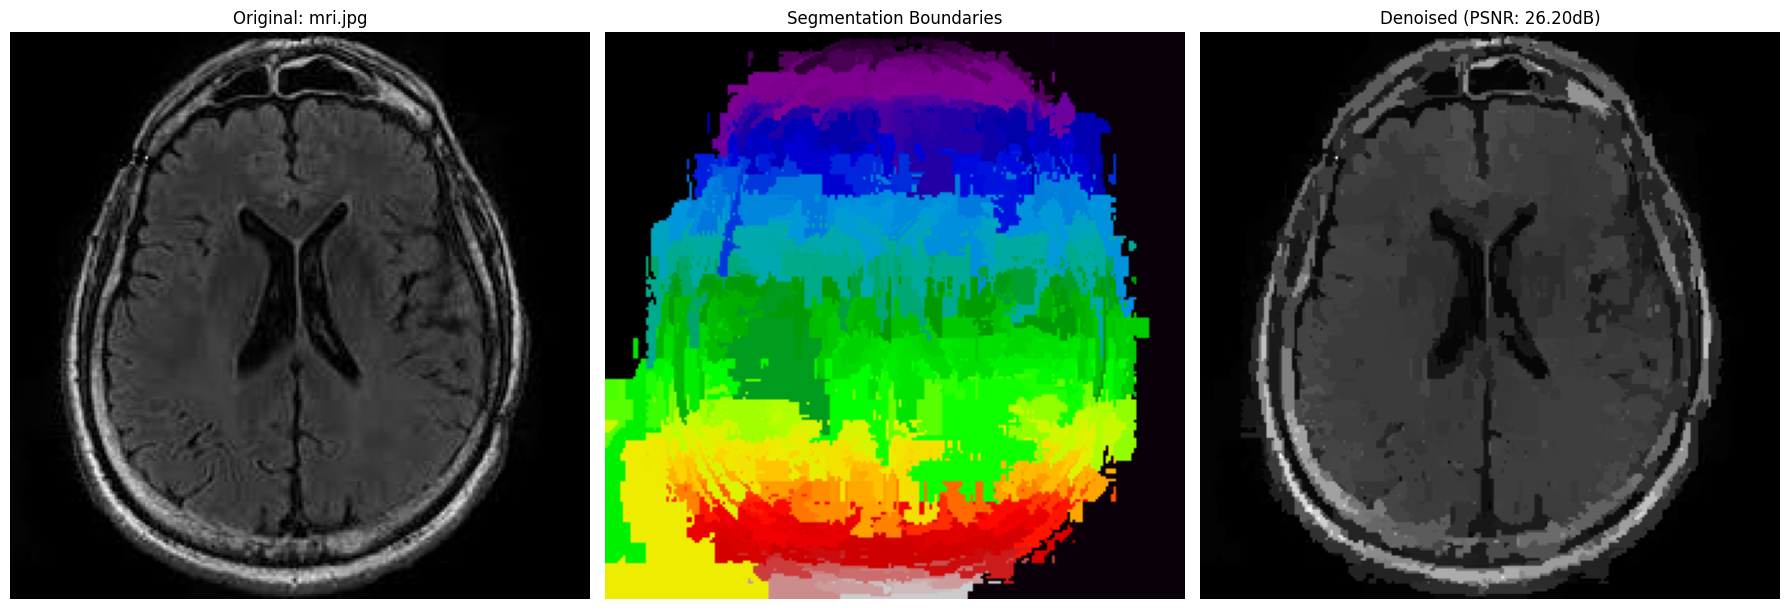

Processing mri2.jpg...


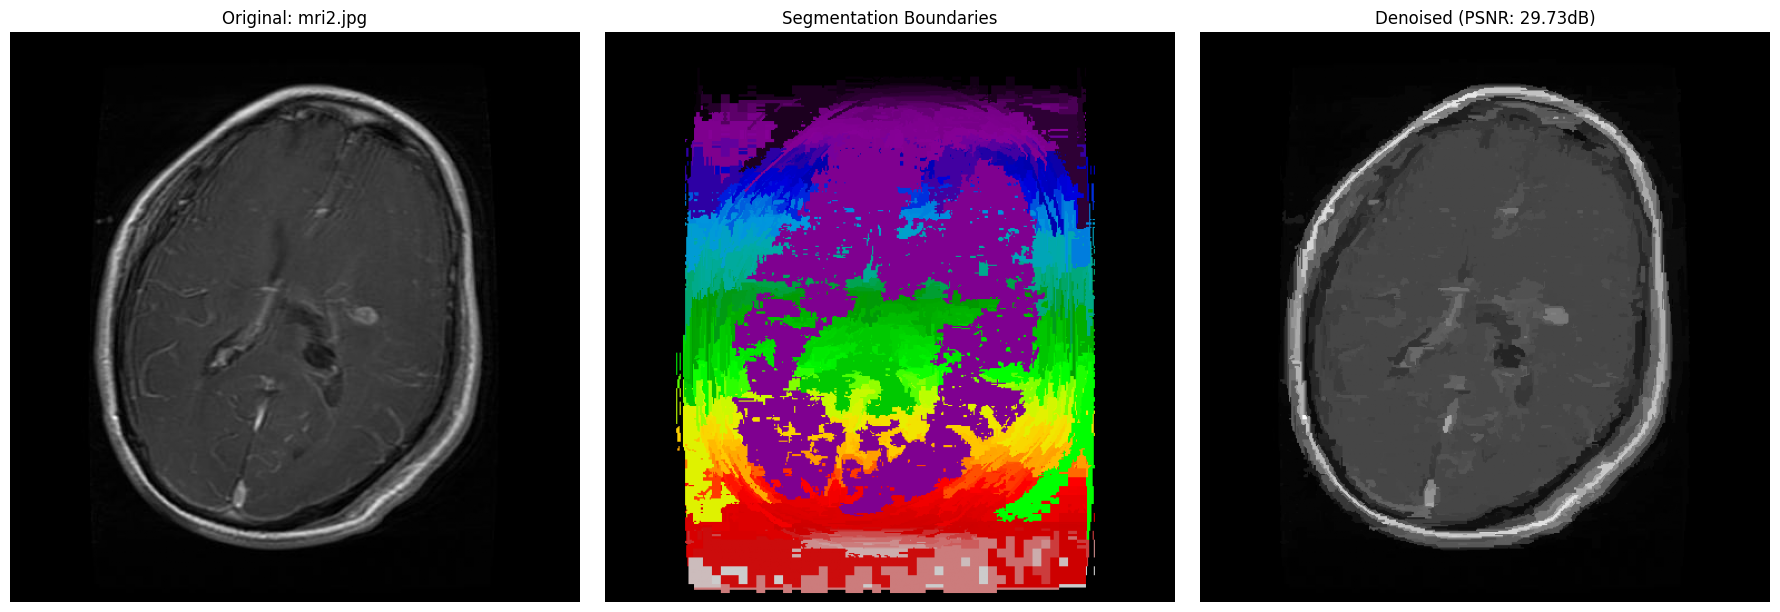

Processing mri3.jpg...


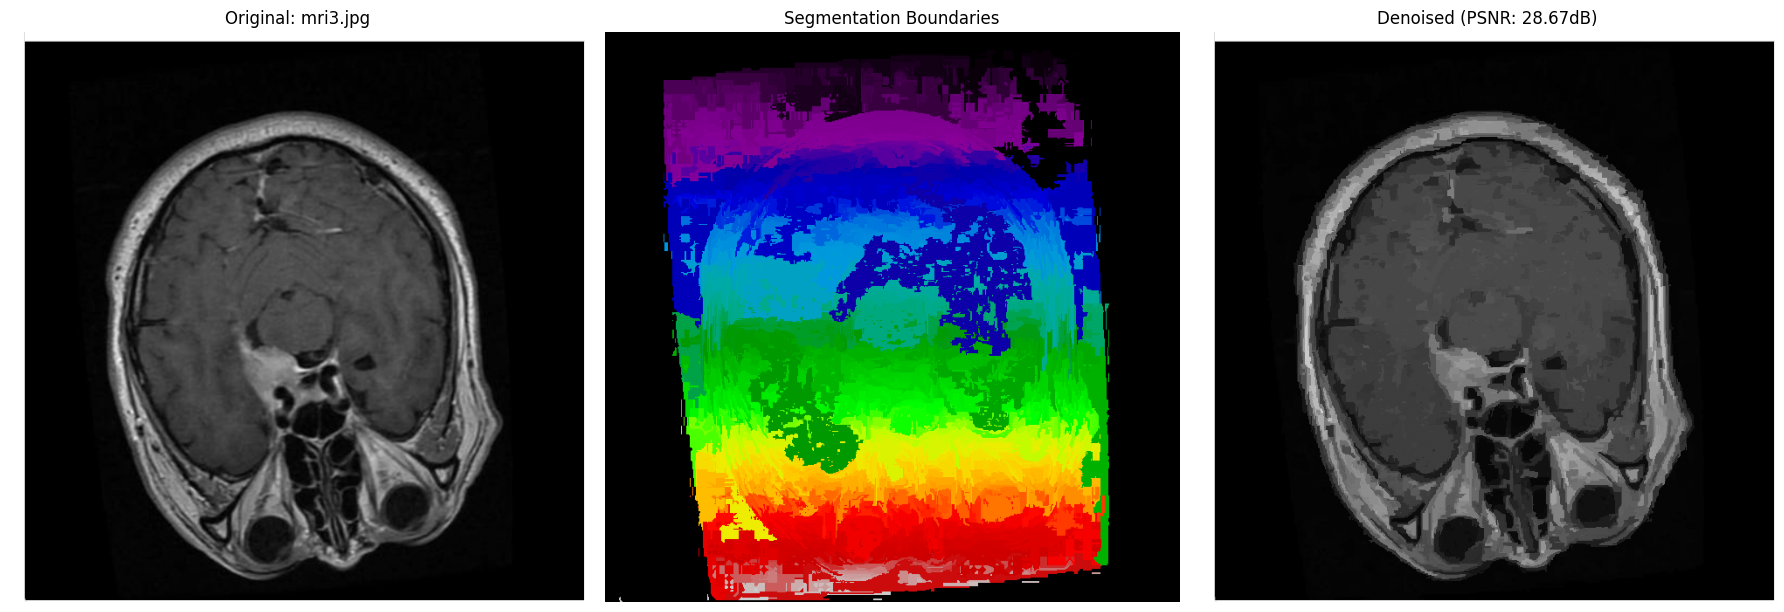

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from scipy import ndimage
from collections import defaultdict
import time
import math
import os

# ==========================================
# 1. UNION-FIND DATA STRUCTURE
# ==========================================
class UnionFind:
    def __init__(self, size):
        self.parent = np.arange(size)
        self.size = np.ones(size)
        self.max_weight = np.zeros(size)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i]) # Path compression [cite: 78]
        return self.parent[i]

    def union(self, i, j, weight):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i
            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            # Update Int(C) as max weight edge in MST [cite: 52]
            self.max_weight[root_i] = max(self.max_weight[root_i], weight)

# ==========================================
# 2. GRAPH CONSTRUCTION & SEGMENTATION
# ==========================================
def build_graph(image):
    rows, cols = image.shape
    edges = []
    # Connect 4-neighbor pixels [cite: 25]
    for i in range(rows):
        for j in range(cols):
            u = i * cols + j
            if j + 1 < cols:
                v = i * cols + (j + 1)
                weight = abs(float(image[i, j]) - float(image[i, j + 1])) # [cite: 40]
                edges.append((weight, u, v))
            if i + 1 < rows:
                v = (i + 1) * cols + j
                weight = abs(float(image[i, j]) - float(image[i + 1, j]))
                edges.append((weight, u, v))
    return edges

def segment_image(image, k):
    rows, cols = image.shape
    num_pixels = rows * cols
    edges = build_graph(image)
    edges.sort(key=lambda x: x[0]) # Sort edges by weight [cite: 43]
    uf = UnionFind(num_pixels)

    for weight, u, v in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)
        if root_u != root_v:
            # tau(C) = k / |C| [cite: 53]
            tau_u = k / uf.size[root_u]
            tau_v = k / uf.size[root_v]
            # Merging criterion [cite: 51]
            if weight <= min(uf.max_weight[root_u] + tau_u, uf.max_weight[root_v] + tau_v):
                uf.union(root_u, root_v, weight)
    return uf

# ==========================================
# 3. SEGMENT-BASED DENOISING (As per Section 3.4)
# ==========================================
def process_output(image, uf):
    rows, cols = image.shape
    denoised = np.zeros_like(image, dtype=np.float64)
    labels = np.zeros((rows, cols), dtype=np.int32)
    segment_sums = defaultdict(float)

    # Map root IDs to a small range (0 to N) for colormap scaling
    root_to_id = {}
    next_id = 0

    # First pass: identify segments and sum intensities [cite: 57, 83]
    for i in range(rows):
        for j in range(cols):
            pixel_idx = i * cols + j
            root = uf.find(pixel_idx)
            if root not in root_to_id:
                root_to_id[root] = next_id
                next_id += 1
            labels[i, j] = root_to_id[root]
            segment_sums[root] += float(image[i, j])

    # Second pass: compute mean intensity per segment [cite: 57, 84]
    for i in range(rows):
        for j in range(cols):
            root = uf.find(i * cols + j)
            denoised[i, j] = segment_sums[root] / uf.size[root]

    return denoised, labels

# ==========================================
# 4. METRICS & VISUALIZATION
# ==========================================
def calculate_metrics(original, denoised):
    mse = np.mean((original.astype(np.float64) - denoised) ** 2) # [cite: 115]
    psnr = 100 if mse == 0 else 20 * math.log10(255.0 / math.sqrt(mse)) # [cite: 116]
    return psnr, mse

def visualize_results(original, labels, denoised, filename, psnr):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(original, cmap='gray')
    axs[0].set_title(f'Original: {filename}')
    axs[0].axis('off')

    # FIX: Use nipy_spectral colormap to match your screenshot
    # This creates the "rainbow" look based on Segment IDs
    axs[1].imshow(labels, cmap='nipy_spectral')
    axs[1].set_title('Segmentation Boundaries')
    axs[1].axis('off')

    axs[2].imshow(denoised, cmap='gray')
    axs[2].set_title(f'Denoised (PSNR: {psnr:.2f}dB)')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 5. MAIN EXECUTION PIPELINE
# ==========================================
def main():
    image_files = ['mri.jpg', 'mri2.jpg', 'mri3.jpg']
    k_val = 100 # Controlling segment size [cite: 54, 109]

    for filename in image_files:
        if not os.path.exists(filename):
            continue

        print(f"Processing {filename}...")
        img = io.imread(filename, as_gray=True)
        if np.max(img) <= 1.0: img *= 255 # Ensure 0-255 range [cite: 23]

        # Execute MST algorithm tasks [cite: 67]
        uf = segment_image(img, k_val)
        denoised, labels = process_output(img, uf)

        psnr, mse = calculate_metrics(img, denoised)
        visualize_results(img, labels, denoised, filename, psnr)

if __name__ == "__main__":
    main()